<a href="https://colab.research.google.com/github/gavrilovAlikhan/ML-Practice/blob/main/Student%20Scores/student_scores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [0]:
%pip install catboost lightgbm optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 19.5 MB/s eta 0:00:00


## Libraries

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, MinMaxScaler

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold, KFold,cross_validate, cross_val_score, cross_val_predict
from sklearn.metrics import root_mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import LinearRegression, Ridge, SGDRegressor

import optuna

import typing

import warnings

In [0]:
import plotly.io as pio
pio.renderers.default = "vscode"

In [0]:
TARGET = "exam_score"
N_SPLITS = 5
SEED = 42

non_relevant_columns = ['id', 'source']

ordinal_maps = {
    "gender" : {"male":0, "female":1, "other":2},
    "internet_access" : {"no":0, "yes":1},
    "sleep_quality" : {"poor":0, "average":1, "good":2},
    "facility_rating" : {"low":0, "medium":1, "high":2},
    "exam_difficulty" : {"easy":0, "moderate":1, "hard":2},
    "course" : {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
    "study_method" : {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
}

original_categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


# Data Loader

In [0]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Student Scores/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

In [0]:
df_train, _, df = load_data(option='colab')

Mounted at /content/drive


# Data Splitter

In [0]:
def data_spliter(df: pd.DataFrame, additional_drop_columns: list = []) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train_dataset = df[df['source'] == 'train'].drop(columns=non_relevant_columns + additional_drop_columns)
    submission_dataset = df[df['source'] == 'test'].drop(columns=['source', TARGET] + additional_drop_columns)

    X_train = train_dataset.drop(columns=[TARGET])
    y_train = train_dataset[TARGET]

    return X_train, y_train, submission_dataset

# EDA

In [0]:
df.isna().sum()

,0
id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900000 entries, 0 to 899999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                900000 non-null  int64  
 1   age               900000 non-null  int64  
 2   gender            900000 non-null  object 
 3   course            900000 non-null  object 
 4   study_hours       900000 non-null  float64
 5   class_attendance  900000 non-null  float64
 6   internet_access   900000 non-null  object 
 7   sleep_hours       900000 non-null  float64
 8   sleep_quality     900000 non-null  object 
 9   study_method      900000 non-null  object 
 10  facility_rating   900000 non-null  object 
 11  exam_difficulty   900000 non-null  object 
 12  exam_score        630000 non-null  float64
 13  source            900000 non-null  object 
dtypes: float64(4), int64(2), object(8)
memory usage: 96.1+ MB


In [0]:
df.drop(columns=non_relevant_columns).describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,900000.0,NaN,NaN,NaN,20.545316,2.260301,17.0,19.0,21.0,23.0,24.0
gender,900000,3,male,301275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
course,900000,7,b.tech,187697,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,900000.0,NaN,NaN,NaN,4.0028,2.359238,0.08,1.98,4.0,6.05,7.91
class_attendance,900000.0,NaN,NaN,NaN,71.985836,17.425469,40.6,57.0,72.6,87.2,99.4
internet_access,900000,2,yes,828094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,900000.0,NaN,NaN,NaN,7.072552,1.745021,4.1,5.6,7.1,8.6,9.9
sleep_quality,900000,3,poor,305355,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_method,900000,5,coaching,188395,NaN,NaN,NaN,NaN,NaN,NaN,NaN
facility_rating,900000,3,medium,305898,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Correlations

In [0]:
z = df.drop(columns=non_relevant_columns).copy()
z['internet_access'] = z['internet_access'].map({'no':0, 'yes':1})
z['sleep_quality'] = z['sleep_quality'].map({'average':1, 'poor':0, 'good':2})
z['facility_rating'] = z['facility_rating'].map({'medium':1, 'low':0, 'high':2})
z['exam_difficulty'] = z['exam_difficulty'].map({'moderate':1, 'easy':0, 'hard':2})
z = pd.get_dummies(z, columns=['study_method', 'course', 'gender'], dtype=int)

In [0]:
z_corr = z.corr()
z_sorted_cols = z_corr['exam_score'].abs().sort_values(ascending=False).index.to_list()

z_corr_sorted = z_corr.loc[z_sorted_cols, z_sorted_cols]
mask = np.triu(np.ones_like(z_corr_sorted, dtype=bool), k=1)
z_corr_sorted[mask] = np.nan

### Correlation Plot

In [0]:
corr_fig = px.imshow(
    z_corr_sorted,
    text_auto = ".2f",
    aspect=True,
    color_continuous_scale="RdBu_r",
    width=1200,
    height=800
)

corr_fig.show()

## Distribution of categorical columns by exam score

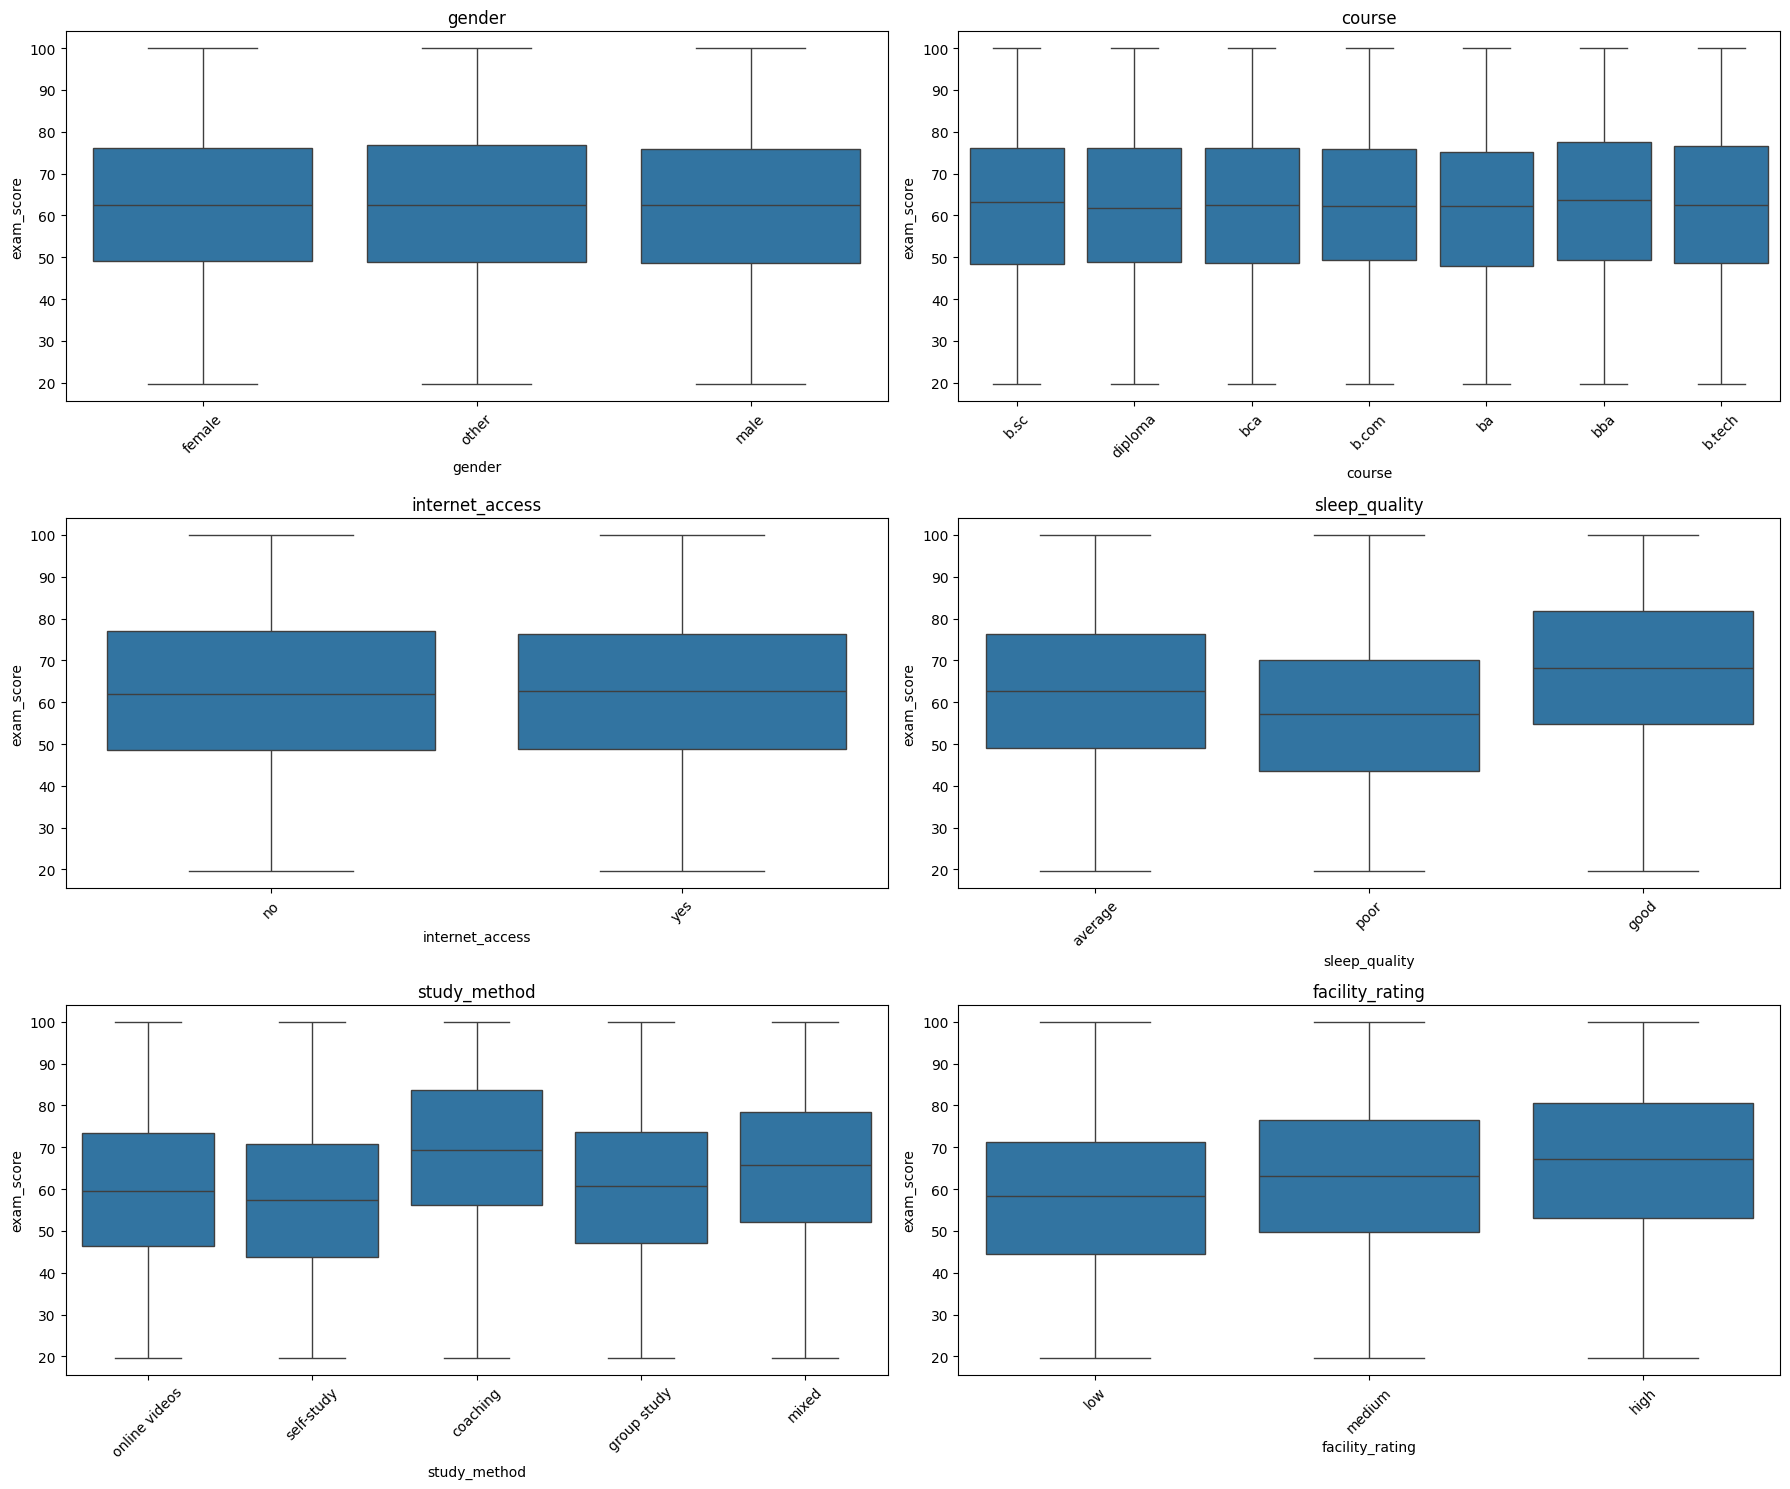

In [0]:
rows = len(original_categorical_cols) // 3 + len(original_categorical_cols) % 3
fig, axes = plt.subplots(rows, 2, figsize=(18, 15))

for ax, c in zip(axes.flat, original_categorical_cols):
    sns.boxplot(data=df, x=c, y="exam_score", ax=ax)
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=45)

# hide any leftover empty panels if you have fewer than 8 columns
for ax in axes.flat[len(original_categorical_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Age

In [0]:
ax = sns.countplot(data=df, x='age', color='lightsteelblue')
ax2 = ax.twinx()
sns.pointplot(data=df, x='age', y=TARGET, ax=ax2, color='crimson', errorbar=None)
sns.pointplot(data=df, x='age', y=TARGET, ax=ax2, color='darkorange', errorbar=None, estimator='median', linestyle='--')

## Attendance

In [0]:
plt.figure(figsize=(10,5))
plot_df = df.copy()
plot_df['bins'] = pd.cut(plot_df['class_attendance'], 10, precision=0)
order = plot_df['bins'].unique().sort_values(ascending=True)

ax = sns.countplot(data=plot_df, x='bins', color='lightsteelblue', order=order)
ax2 = ax.twinx()
sns.pointplot(data=plot_df, x='bins', y=TARGET, ax=ax2, color='crimson', errorbar=None)
sns.pointplot(data=plot_df, x='bins', y=TARGET, ax=ax2, color='darkorange', errorbar=None, estimator='median', linestyle='--')

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## Course

In [0]:
col = 'course'
order = df.groupby(col)[TARGET].median().sort_values().index
ax = sns.countplot(data=df, x=col, color='lightsteelblue', order=order)
ax2 = ax.twinx()
sns.pointplot(data=df, x=col, y=TARGET, ax=ax2, color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=df, x=col, y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')
ax2.legend()

## Sleep Quality

In [0]:
plt.figure(figsize=(8,5))
plot_df = df.copy()
plot_df['sleep_bins'] = pd.cut(df.sleep_hours, 10, precision=0)
stats = plot_df.groupby('sleep_bins')['exam_score'].agg(['mean', 'median'])

order = sorted(plot_df.sleep_bins.unique().tolist())

ax = sns.countplot(plot_df, x='sleep_bins', order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x='sleep_bins', y=TARGET, ax=ax2, color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x='sleep_bins', y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Study Hours

In [0]:
col = 'study_hours'
bin_col = f'{col}_bins'

plt.figure(figsize=(8,5))
plot_df = df.copy()
plot_df[bin_col] = pd.cut(df[col], 10, precision=0)
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = sorted(plot_df[bin_col].unique().tolist())

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Study Method

In [0]:
col = 'study_method'
bin_col = col

plt.figure(figsize=(8,5))
plot_df = df.copy()
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = stats.sort_values(by='median').index.tolist()

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', errorbar=None, label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange', errorbar=None,
              estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

## Internet Acces

In [0]:
col = 'internet_access'
bin_col = col

plt.figure(figsize=(8,5))
plot_df = df.copy()
stats = plot_df.groupby(bin_col)[TARGET].agg(['mean', 'median'])

order = stats.sort_values(by='median').index.tolist()

ax = sns.countplot(plot_df, x=bin_col, order=order)
ax2 = ax.twinx()

sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2,color='crimson', label='Mean')
sns.pointplot(data=plot_df, x=bin_col, y=TARGET, ax=ax2, color='darkorange',estimator='median', linestyles='--', markers='s', label='Median')

plt.tight_layout()

# Feature Engineering

In [0]:
df.head()

In [0]:
ordinal_maps.keys()

In [0]:
for k, i in ordinal_maps.items():
    print(i)
    print(k)

In [0]:
def feature_engineering(fdf: pd.DataFrame):
    df = fdf.copy()
    for k, i in ordinal_maps.items():
        df[k] = df[k].map(i)
    return df

In [0]:
_, _, df = load_data()

In [0]:
df = feature_engineering(df)

In [0]:
cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

# Ridge Regression

In [0]:
X, y, submission_df = data_spliter(df)
y_bins = pd.cut(y, 10, precision=0, labels=False)

In [0]:
oof = np.zeros(len(X))

In [0]:
model = make_pipeline(StandardScaler(), Ridge(alpha=10))

oof = cross_val_predict(model, X, y, cv=cv)
print(f"OOF RMSE: {root_mean_squared_error(y, oof):.4f}")

OOF RMSE: 8.9641


In [0]:
print(root_mean_squared_error(y, oof))

8.964110371610925


In [0]:
for fold, (train_idx, val_idx) in enumerate(cv.split(X, y_bins)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = Ridge(alpha=1.0, random_state=SEED)

    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    val_preds = model.predict(X_val)